Projeler: Senin listenden 7 tane:

Yapay Sinir Ağları ile Görüntü Sınıflandırma (MLP) -yapmıştım tekrar yapmicam

CNN ile Rakam Görüntüsü Sınıflandırma (MNIST) -yapmıştım tekrar yapmicam

LSTM ile Film Yorumları Duygu Analizi

GAN ile Görüntü Oluşturma

Transformers ile Duygu Analizi (Text)

Autoencoder ile Moda Görüntüleri (Fashion-MNIST)

Transfer Learning ile İlaç Görüntüleri Sınıflandırma

**Autoencoder ile Moda Görüntüleri (Fashion-MNIST)**

100%|██████████| 26.4M/26.4M [00:02<00:00, 9.93MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 173kB/s]
100%|██████████| 4.42M/4.42M [00:01<00:00, 3.16MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 27.1MB/s]


Epoch [1/5], Loss: 0.0454
Epoch [2/5], Loss: 0.0233
Epoch [3/5], Loss: 0.0207
Epoch [4/5], Loss: 0.0189
Epoch [5/5], Loss: 0.0178


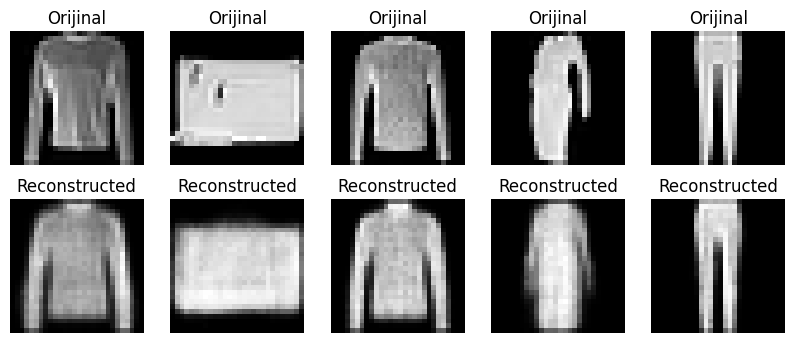

In [1]:
# 🔹 1️⃣ Kütüphaneler
import torch  # PyTorch: tensor ve GPU işlemleri için
import torch.nn as nn  # sinir ağı katmanları için
import torch.optim as optim  # optimizer (modeli güncellemek için)
import torchvision  # hazır datasetler ve dönüşümler
import torchvision.transforms as transforms  # görüntü dönüşümleri (ToTensor vs)
import matplotlib.pyplot as plt  # görselleştirme için

# 🔹 2️⃣ Device (CPU/GPU kontrolü)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")  # GPU varsa kullan, yoksa CPU

# 🔹 3️⃣ Dataset + DataLoader
transform = transforms.ToTensor()  # görüntüleri 0-1 aralığına çevirir ve tensor yapar
train_dataset = torchvision.datasets.FashionMNIST(
    root="./data",  # veri klasörü
    train=True,  # eğitim verisi
    download=True,  # dataset yoksa indirir
    transform=transform
)

train_loader = torch.utils.data.DataLoader(
    train_dataset,
    batch_size=128,  # daha büyük batch, GPU varsa daha hızlı
    shuffle=True
)

# 🔹 4️⃣ Autoencoder Modeli
class Autoencoder(nn.Module):  # nn.Module’dan miras alıyoruz; PyTorch modelinin temel sınıfı
    def __init__(self):  # sınıfın başlatıcı fonksiyonu, modelin katmanlarını burada tanımlarız
        super(Autoencoder, self).__init__()  # nn.Module'u başlatır, miras aldığımız yapı
        # Encoder: görüntüyü küçültür / sıkıştırır
        self.encoder = nn.Sequential(  # Katmanları sıralı şekilde uygulamak için Sequential kullandık
            nn.Flatten(),  # 28x28 görüntüyü tek boyutlu 784 elemana dönüştürür
            nn.Linear(28*28, 128),  # 784 giriş → 128 çıkış (sıkıştırma boyutu)
            nn.ReLU(True),  # Aktivasyon fonksiyonu, negatif değerleri sıfırlar, True inplace değişim yapar
            nn.Linear(128, 64),  # 128 → 64, boyutu daha da sıkıştırıyoruz
            nn.ReLU(True),  # aynı şekilde ReLU, non-lineerlik katar
            nn.Linear(64, 32),  # 64 → 32, latent space boyutu (görselin özü)
        )
        # Decoder: küçültülmüş boyutu geri 28x28 yapar
        self.decoder = nn.Sequential(
            nn.Linear(32, 64),  # latent 32 → 64
            nn.ReLU(True),  # aktivasyon, negatif değerleri sıfırlar
            nn.Linear(64, 128),  # 64 → 128, tekrar genişletiyoruz
            nn.ReLU(True),  # aktivasyon
            nn.Linear(128, 28*28),  # 128 → 784, orijinal boyuta geri dönüyor
            nn.Sigmoid(),  # 0-1 aralığına normalize eder, çünkü input da 0-1 aralığında
            nn.Unflatten(1, (1, 28, 28))  # 784 boyutlu vektörü tekrar 28x28 şekline çevirir
        )

    def forward(self, x):  # modelin ileri besleme fonksiyonu
        x = self.encoder(x)  # görüntüyü encoder katmanlarından geçirir, boyutu küçültür
        x = self.decoder(x)  # küçültülmüş boyutu decoder ile tekrar 28x28'e çevirir
        return x  # output olarak reconstructed görüntüyü döndürür

# 🔹 5️⃣ Modeli oluştur ve GPU/CPU’ya taşı
model = Autoencoder().to(device)  # Autoencoder sınıfından model oluştur, device'a (GPU/CPU) taşı

# 🔹 6️⃣ Loss ve Optimizer
criterion = nn.MSELoss()  # Loss fonksiyonu: reconstructed (çıktı) ve orijinal görüntü arasındaki farkı ölçer
optimizer = optim.Adam(model.parameters(), lr=1e-3)  # Adam optimizer ile ağırlıkları günceller, lr=learning rate

# 🔹 7️⃣ Eğitim Döngüsü
num_epochs = 5  # kaç defa tüm dataset üzerinden geçeceğiz, demo için 5 epoch yeterli

for epoch in range(num_epochs):  # her epoch için döngü başlat
    running_loss = 0.0  # epoch başında loss sıfırla
    for images, _ in train_loader:  # train_loader’dan batch al, etiketler kullanılmaz
        images = images.to(device)  # batch’i GPU/CPU’ya gönder

        optimizer.zero_grad()  # 1️⃣ gradientleri sıfırla (önceki adımlardan kalmasın)

        outputs = model(images)  # 2️⃣ forward pass: modelden geçir, output reconstruction

        loss = criterion(outputs, images)  # 3️⃣ loss hesapla: output vs input

        loss.backward()  # 4️⃣ backward pass: gradient hesapla (backpropagation)

        optimizer.step()  # 5️⃣ ağırlıkları güncelle (optimizer ile)

        running_loss += loss.item()  # loss’u topla (ortalama için)

    print(f"Epoch [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}")  # epoch sonunda loss yazdır

# 🔹 8️⃣ Sonuçları Görselleştirme
dataiter = iter(train_loader)  # loader’dan iterator oluştur
images, _ = next(dataiter)  # iterator’dan bir batch al (ilk 64 görüntü)
images = images.to(device)  # GPU/CPU’ya taşı
outputs = model(images)  # batch’i modelden geçir, reconstruction al

plt.figure(figsize=(10,4))  # matplotlib figure boyutu

for i in range(5):  # ilk 5 görüntü için
    # Orijinal görüntü
    plt.subplot(2,5,i+1)  # 2 satır, 5 sütun, konum
    plt.imshow(images[i].cpu().squeeze(), cmap='gray')  # GPU tensor → CPU, squeeze gereksiz boyutu kaldır
    plt.title("Orijinal")  # başlık
    plt.axis('off')  # eksenleri gizle

    # Reconstruction görüntü
    plt.subplot(2,5,i+6)  # alt satır
    plt.imshow(outputs[i].cpu().detach().squeeze(), cmap='gray')  # GPU tensor → CPU, detach = gradient bağlantısını kopar
    plt.title("Reconstructed")  # başlık
    plt.axis('off')  # eksenleri gizle

plt.show()  # grafiği göster